In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings 
warnings.filterwarnings('ignore')

In [3]:
# Read the dataset 
df =pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


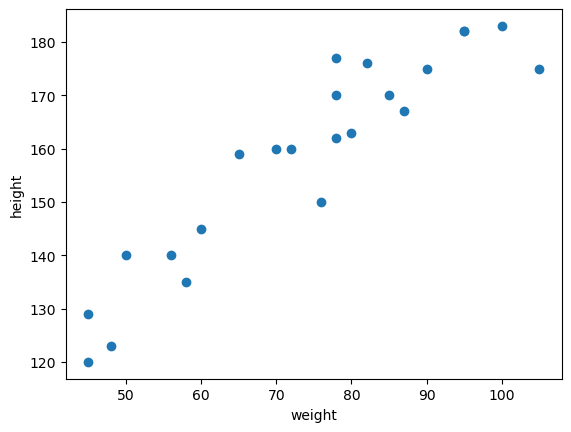

In [5]:
plt.scatter(df.Weight,df.Height)
plt.xlabel('weight')
plt.ylabel('height')
plt.show()

### Problem Statement >> I want to predit height based on weight 

### Divied thge data int X and Y

In [7]:
x = df[['Weight']]
y = df[['Height']]
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [8]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [10]:
# train test split

from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test= train_test_split(x,y,test_size =0.25,random_state = 1)

In [11]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [12]:
x_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [13]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [14]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [15]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((17, 1), (17, 1), (6, 1), (6, 1))

##### Scaling(optionl) >> Standardization -> fit_transform on train data and transform on test data 
##### if you use fit on test data , (that is wrong ) you are doing data leakage , avoid it 
# most of the ml model StandardScaler is used as it deals with normal distribution

In [16]:
from sklearn.preprocessing import StandardScaler


In [17]:
Scaler = StandardScaler()
Scaler

StandardScaler()

In [19]:
# scaling should be done always train test split 
# target variable should not be scaled 
# avoiding scaling categorical features 



x_train = Scaler.fit_transform(x_train)   # for train data use fit_transform
x_test = Scaler.transform(x_test)   # for test data use transform

In [20]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [21]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

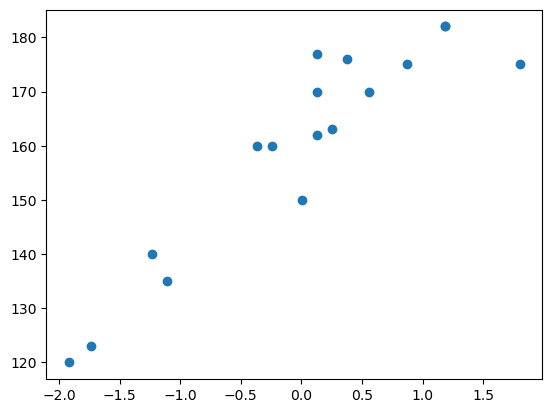

In [22]:
# Scaling is optional >> why because it doesnot affect the distibution of data
plt.scatter(x_train,y_train)

In [23]:
# model training 

from sklearn.linear_model import LinearRegression

# Linear regression parameters
# fit_intercept >>The best fit line will have intercept , by default it is true

# copy_x >> copy the original x_train and then build the model , it will not modify the orginal data

# n_jobs >> -1 means using all processors 
# positive >> when set to true , forces the coeeficient to positive .

# fit >> train the model 
# predict >> test the model 

# after building the model , you have attributes of the model 
# coef_\
# intercept 

In [24]:
Regressor = LinearRegression()
Regressor

LinearRegression()

In [25]:
Regressor.fit(x_train , y_train)

LinearRegression()

In [26]:
Regressor.coef_

array([[17.7307072]])

In [27]:
Regressor.intercept_

array([160.])

In [28]:
print("The Slope or coeff of model is " , Regressor.coef_)
print("The Slope or intercept  of model is " , Regressor.intercept_)

The Slope or coeff of model is  [[17.7307072]]
The Slope or intercept  of model is  [160.]


In [29]:
#  Prediction on train data 
# interpretation of coeff > one unit increses in weight ,on an average the hight incresed by 17.73

# predictied hight (y ) on xtrain = 160 + 17.73*(x_train)
# predictied hight (y ) on xtest = 160 + 17.73*(x_test)

In [30]:
# prediction on train data 
Regressor.predict(x_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

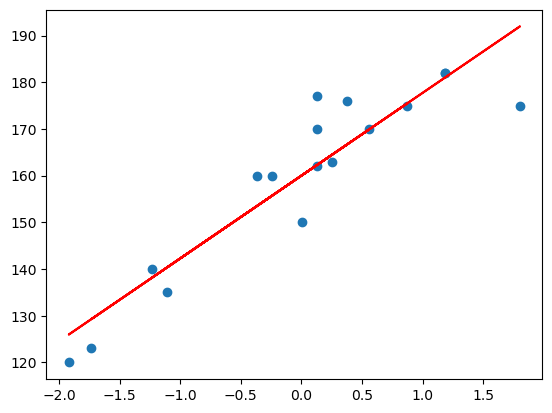

In [32]:
plt.scatter(x_train , y_train)
plt.plot(x_train ,Regressor.predict(x_train) , color = 'red' )

In [34]:
y_pred_test = Regressor.predict(x_test)
y_pred_test ,y_test

(array([[125.99571945],
        [147.97567266],
        [142.48068436],
        [186.44059077],
        [172.15362118],
        [131.49070775]]),
     Height
 20     129
 17     159
 3      145
 13     183
 19     167
 16     140)

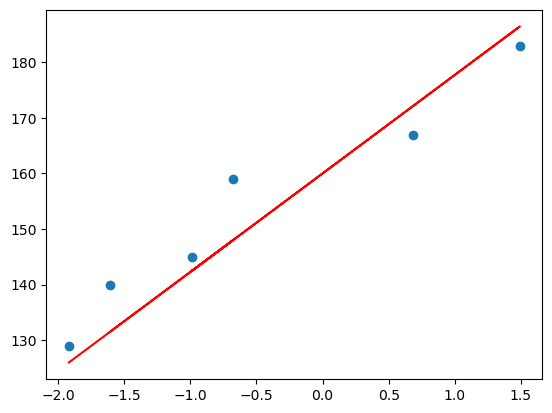

In [36]:
plt.scatter(x_test , y_test)
plt.plot(x_test ,Regressor.predict(x_test) , color = 'red' )

In [37]:
# performnace matrics

In [38]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [39]:
mean_absolute_error(y_test , y_pred_test)

5.608571289304838

In [40]:
mean_squared_error(y_test , y_pred_test)

41.285662830455514

In [46]:
rsq = r2_score(y_test , y_pred_test) # rsquare  = 1-ssr/tss
rsq

0.8721036174256606

In [43]:
# Adjusted rsquare  -> [1-(1-rsquare)*(n-1)/(n-k-1)]


In [47]:
x_test.shape[1]

1

In [50]:
1-(1-rsq)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

# Adjusted rsqure will be lesser than r square 

0.8401295217820757

In [51]:
# assumption 
# x-y should have linear relationship
# observation should have no realtion 
# error should be normally distributed 
# error should have constant variation 
# features among themself should be least realted 

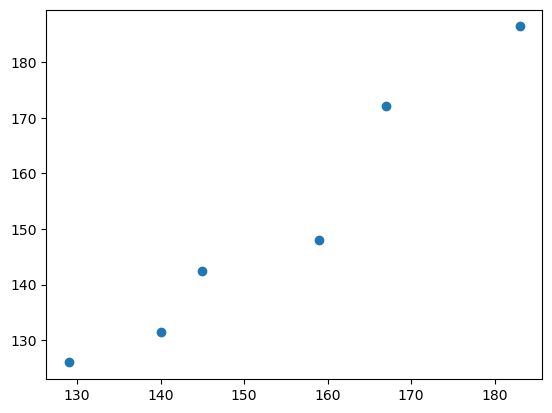

In [52]:
plt.scatter(y_test , y_pred_test)
 # to check if y_test and its prediction aligns 

In [53]:
# error should be normally distributed 
# error should have constant variation


error = y_test - y_pred_test
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


<Axes: ylabel='Density'>

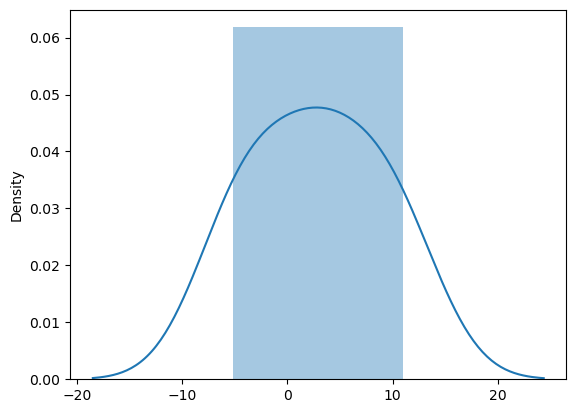

In [54]:
sns.distplot(error) # aproximately it is normally distribution

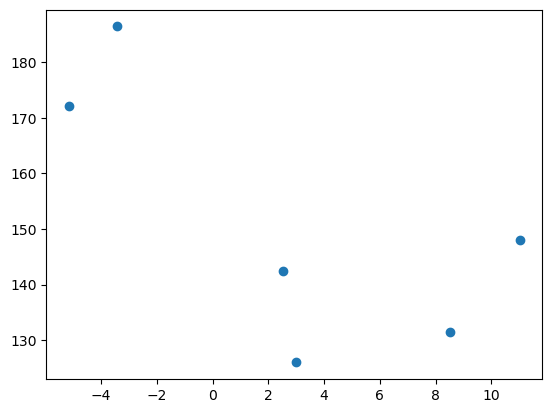

In [55]:
# to check variance 
plt.scatter(error , y_pred_test)